# Performing deDANSy on an RNA-sequencing dataset (Shimpi & Tan et al. 2021)

Note: This come directly from the supplementary file provided with the publication. This is based on a RNA-sequencing dataset which requires converting between ENSEMBL gene IDs to UniProt IDs.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pybiomart import Dataset

import dansy

In [2]:
# First need to import and create an ID conversion dataframe
bm_dataset = Dataset(host = 'http://useast.ensembl.org', name='hsapiens_gene_ensembl',)
gene_ID_conv = bm_dataset.query(attributes=['ensembl_gene_id','external_gene_name','uniprotswissprot'])

# Importing the proteome reference file
ref = dansy.import_proteome_files()

In [3]:
# Now importing the data of interest
input_dir = './'
filename = 'Shimpi_Tan_RNA_seq_Results.csv'
data = pd.read_csv(input_dir+filename)

In [4]:
# Now building the deDANSy object
my_dedansy = dansy.DEdansy(uniprot_ref = ref, 
                           dataset=data,
                            id_conv=gene_ID_conv,
                            conv_cols = 'Gene stable ID',
                            data_ids = 'ensembl_gene_id')

# And now creating the metadata for designating differentially expressed genes
my_dedansy.create_contrast_metadata(comparisons = ['HAS2_v_Control','HAS3_v_Control'],
                                    fc_cols = ['log2FoldChange_HAS2','log2FoldChange_HAS3'],
                                    pval_cols = ['padj_HAS2','padj_HAS3'],
                                    fcs = 1,
                                    alphas = 0.05)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.
Building the reference network information.


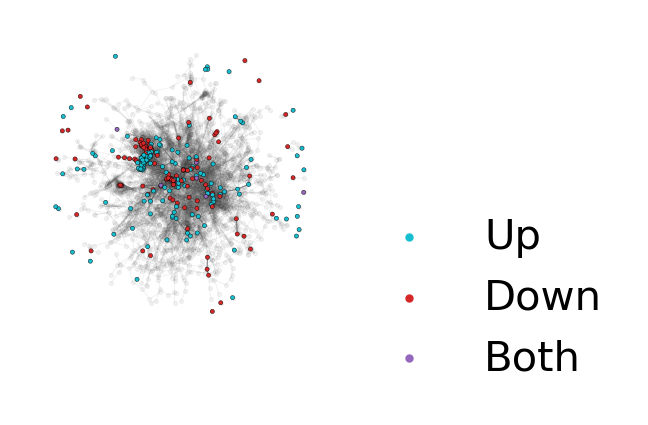

In [5]:
# The deDANSy object now has several built-in functions that allow for quick visualization of the n-gram network colored by whether n-grams are associated with up- or down-regulated genes.

# Setting up the DEG condition
my_dedansy.calc_DEG_ngrams('HAS2_v_Control')

# Now establishing the layout of the network and then visualizing
pos = nx.spring_layout(my_dedansy.G, k = 0.04, seed = 123)
my_dedansy.plot_DEG_ns(pos=pos)
plt.gcf().set_size_inches(1,1)
plt.gcf().set_dpi(300)


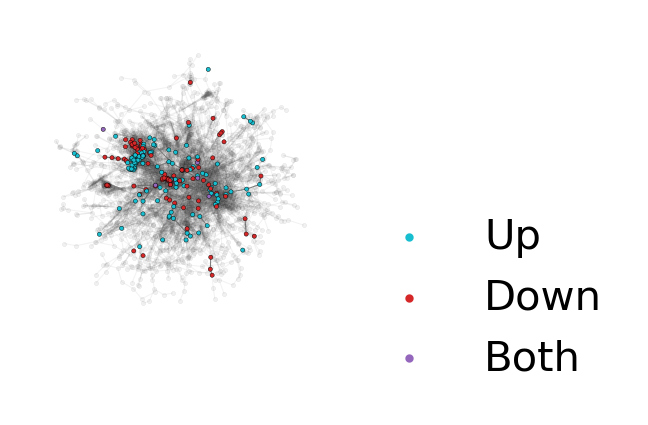

In [6]:
# If you only want to focus on the largest connected component:
my_dedansy.plot_DEG_ns(pos=pos, large_cc_mode=True)
plt.gcf().set_size_inches(1,1)
plt.gcf().set_dpi(300)

While visualizing the network provides an initial assessment of how distinct n-grams from each condition are, to get a more quantitative value we can calculate the separation and distinction scores from the actual deDANSy algorithm.

In [7]:
# The algorithm can be run on multiple conditions in one round
my_dedansy.calculate_scores(comps = ['HAS2_v_Control', 'HAS3_v_Control'],
                            num_ss_trials=20, # Lower than recommended to save time (Default value of 100 is recommended)
                            fpr_trials=5, # Lower than recommended to save time (Default value of 50 is recommended)
                            min_pval=-10,
                            processes=8,
                            seed=123, # For reproducibility but can be omitted
                            verbose=True)

2025-10-08 17:08:42:.....Starting deDANSy scoring analysis with random seed: 123
2025-10-08 17:08:53:.....Done with enrichment-based pruning for HAS2_v_Control
2025-10-08 17:09:09:.....Done with enrichment-based pruning for HAS3_v_Control
2025-10-08 17:09:09:.....Starting the false positive rate procedure.
2025-10-08 17:09:57:.....Finished FPR procedure for HAS2_v_Control.
2025-10-08 17:10:58:.....Finished FPR procedure for HAS3_v_Control.
2025-10-08 17:10:58:.....Preparing the FPR results for export


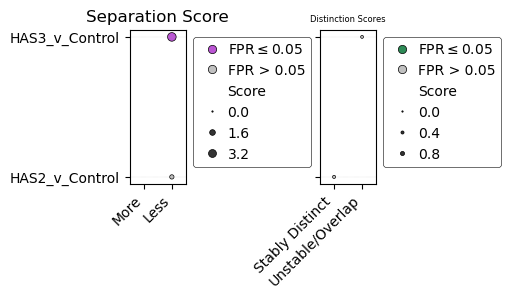

In [8]:
# We can then display each of the scores as a bubble plot
axs = my_dedansy.plot_scores(aspect=5) # The aspect parameter changes the aspect ratio which can make the graph a bit more aesthetically pleasing.
plt.gcf().set_dpi(100)
plt.gcf().set_size_inches(4.5,2)

In [9]:
# A more in-depth table of the results can be displayed or saved using the scores parameter, which includes both the Mann-Whitney U significance test and the FPR results.
my_dedansy.scores

,Comparison,Separation_Score,Separation_Category,Separation_p,Separation_FPR,Distinction_Score,Distinction_Category,Distinction_p,Distinction_FPR
Comparison,,,,,,,,,
HAS2_v_Control,HAS2_v_Control,0.882058,Less,1.058121e-02,0.4,0.413433,Stably Distinct,0.694891,1.0
HAS3_v_Control,HAS3_v_Control,3.824758,Less,6.795615e-08,0.0,0.344319,Unstable/Overlapping,0.239324,0.2


## Running additional comparisons after scores have been generated

Sometimes, you may want to add in additional comparisons, which are either additional biological comparisons not explored, or to be more restrictive in what is designated as a differentially expressed gene/protein. You can add in additional comparisons after scores have been calculated and then run a second time with new comparisons to allow additional analysis to be conducted.

In [10]:
my_dedansy.create_contrast_metadata(comparisons = ['HAS2_restrictive', 'HAS3_restrictive'],
                                    fc_cols = ['log2FoldChange_HAS2','log2FoldChange_HAS3'],
                                    pval_cols = ['padj_HAS2','padj_HAS3'],
                                    fcs = 1,
                                    alphas = 0.001)
my_dedansy.calculate_scores(comps = ['HAS2_restrictive', 'HAS3_restrictive'],
                            num_ss_trials=20, # Lower than recommended to save time (Default value of 100 is recommended)
                            fpr_trials=5, # Lower than recommended to save time (Default value of 50 is recommended)
                            min_pval=-10,
                            processes=8,
                            seed=123, # For reproducibility but can be omitted
                            verbose=True)


2025-10-08 17:10:59:.....Starting deDANSy scoring analysis with random seed: 123
2025-10-08 17:11:08:.....Done with enrichment-based pruning for HAS2_restrictive
2025-10-08 17:11:21:.....Done with enrichment-based pruning for HAS3_restrictive
2025-10-08 17:11:21:.....Starting the false positive rate procedure.
2025-10-08 17:12:05:.....Finished FPR procedure for HAS2_restrictive.
2025-10-08 17:13:01:.....Finished FPR procedure for HAS3_restrictive.
2025-10-08 17:13:01:.....Preparing the FPR results for export


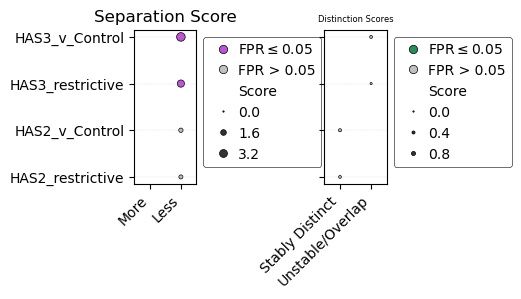

In [11]:
axs = my_dedansy.plot_scores(aspect=1.5) # The aspect parameter changes the aspect ratio which can make the graph a bit more aesthetically pleasing.
plt.gcf().set_dpi(100)
plt.gcf().set_size_inches(4.5,2)

In [12]:
my_dedansy.comp_metadata

,fc_col,fc_thres,pval_col,alpha
HAS2_v_Control,log2FoldChange_HAS2,1,padj_HAS2,0.05
HAS3_v_Control,log2FoldChange_HAS3,1,padj_HAS3,0.05
HAS2_restrictive,log2FoldChange_HAS2,1,padj_HAS2,0.001
HAS3_restrictive,log2FoldChange_HAS3,1,padj_HAS3,0.001


# Determining the enriched n-grams of individual conditions.

In addition to generating scores for network wide behavior, deDANSy can get the significantly enriched n-grams for both up- and down-regulated proteins/genes. Like how DANSy collapses n-grams representing similar data, the n-gram enrichment calculation collapses n-grams that have similar significance values that have a parent-children relationship (i.e. shorter n-gram in a longer n-gram).

Will be overwriting existing DEG data.


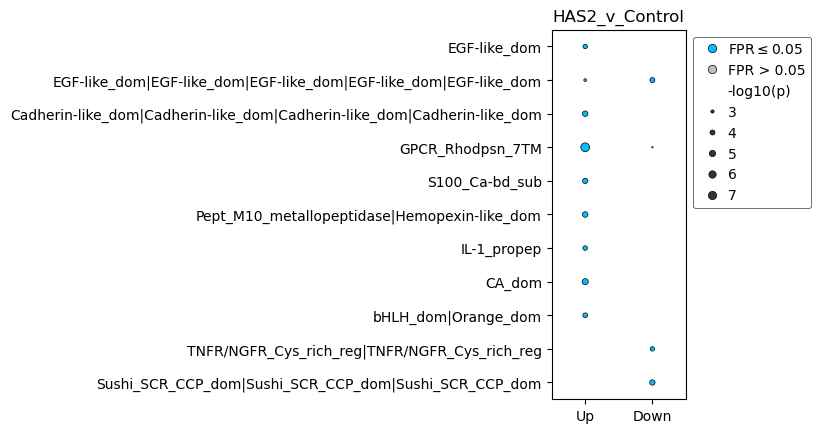

In [13]:
my_dedansy.calculate_ngram_enrichment('HAS2_v_Control')
my_dedansy.plot_ngram_enrichment('HAS2_v_Control')

# And just like before can adjust the aspect ratio to make it a little more aesthetically pleasing.
plt.gca().set_aspect(.5)
plt.title('HAS2_v_Control')
plt.show()

Each comparison can have its own plot to show the unique/shared n-grams for each comparison.

Will be overwriting existing DEG data.


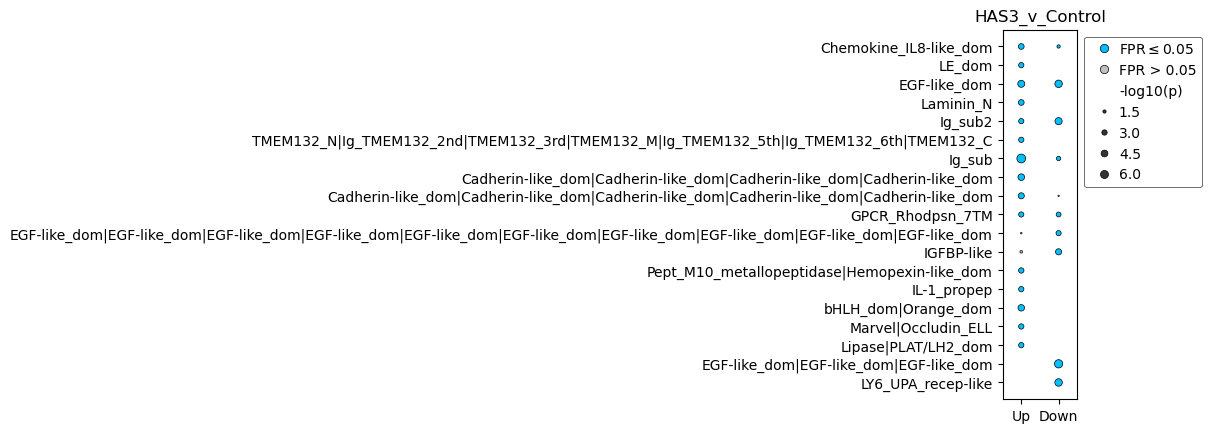

In [14]:
my_dedansy.calculate_ngram_enrichment('HAS3_v_Control')
my_dedansy.plot_ngram_enrichment('HAS3_v_Control')

# And just like before can adjust the aspect ratio to make it a little more aesthetically pleasing.
plt.gca().set_aspect(.5)
plt.title('HAS3_v_Control')
plt.show()

The displayed n-grams can be adjusted to pass a more lenient/restrictive cutoff for being displayed. We can use either a p-value cutoff (p parameter) or a quantile cutoff (q parameter) to change the plot behavior.

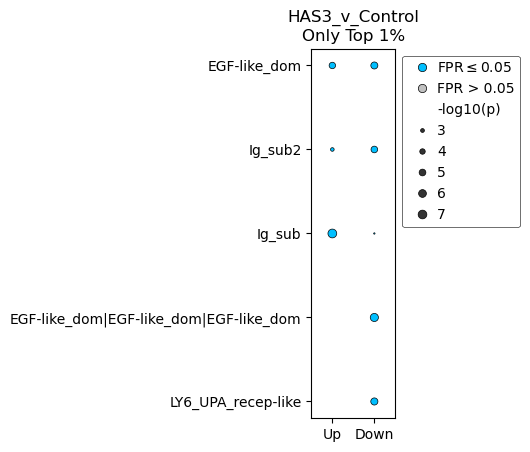

In [15]:
my_dedansy.plot_ngram_enrichment('HAS3_v_Control',q=0.01)
plt.gca().set_aspect(2)
plt.title('HAS3_v_Control\nOnly Top 1%')
plt.show()

If you want to check the full n-gram enrichment data used for plotting, you can use the get_ngram_results method for the comparison of interest

In [16]:
my_dedansy.get_ngram_results('HAS2_v_Control')

,variable,ngram_legible,ngram,p,-log10(p),FPR,FPR <= 0.05
0,Up,Znf_C2H2_type|Znf_C2H2_type|Znf_C2H2_type|Znf_...,IPR013087|IPR013087|IPR013087|IPR013087|IPR013...,0.998364,0.000711,1.000000,False
1,Up,Znf_C2H2_type|Znf_C2H2_type|Znf_C2H2_type,IPR013087|IPR013087|IPR013087,0.997764,0.000972,1.000000,False
2,Up,Small_GTP-bd,IPR005225,0.546010,0.262799,0.346667,False
3,Up,RRM_dom,IPR000504,0.930060,0.031489,0.914286,False
4,Up,SH3_domain,IPR001452,0.754723,0.122212,0.704225,False
...,...,...,...,...,...,...,...
567,Down,LamG-like|Notch_dom|Notch_dom|Sushi_SCR_CCP_do...,IPR006558|IPR000800|IPR000800|IPR000436|IPR000...,0.007810,2.107342,0.000000,True
568,Down,WW_dom|PDZ|FERM_domain,IPR001202|IPR001478|IPR000299,0.007810,2.107342,0.000000,True
569,Down,LCCL|VWF_A|VWF_A,IPR004043|IPR002035|IPR002035,0.007810,2.107342,0.000000,True
570,Down,MyBP-C_THB|Ig_sub|Ig_sub2|Ig_sub|Ig_sub2|FN3_d...,IPR040849|IPR003599|IPR003598|IPR003599|IPR003...,0.007810,2.107342,0.000000,True


# Performing deDANSy analysis with (phospho-)proteomic data

If you are working with a proteomic dataset and do not require converting IDs because you are using UniProt IDs, you can build a deDANSy object without the conversion and perform analysis as outlined below with a phosphoproteomic dataset from [Chen et al, 2024](https://doi.org/10.1158/1535-7163.MCT-23-0218). We are using Supplementary Table S5 specifically.

In [17]:
# Importing the data
filename = 'CUTO28_pY_Results.xlsx'
raw_phos = pd.read_excel(filename,header=1)

# First filtering out the raw data to ensure we only have the human data and those found within our reference file.
proc_phos = raw_phos[raw_phos['IsHuman'] == 1]
proc_phos = proc_phos[proc_phos['Protein'].isin(ref['UniProt ID'])]

In [18]:
# Now building the deDANSy object, which can ignore any ID conversion by setting the run_conversion parameter to False.
prot_dedansy = dansy.DEdansy(dataset = proc_phos,
                             uniprot_ref = ref,
                             data_ids = 'Protein',
                             run_conversion = False)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.
Building the reference network information.


After this the process of calculating scores and plotting them is identical.